Long-term impact results of PAH toxicity from MPRI2 spill scenarios at Turn Point/Haro Strait

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Define scenario and control files

| Scenarios	|	Description |
|-----------|---------------|
| 1	|	no management |
| 2 |   30-day fisheries closures |
| 3	|	90-day fisheries closures |
| 4	|	spill containment within 48hrs |
| 5	|	spill containment within 48hrs + 30-day fisheries closures |
| 6	|	spill containment within 48hrs + 90-day fisheries closures |

8 simulations for each scenario
1. winter S winds
1. winter N winds
1. spring opposing winds & currents
1. spring tandem winds & currents
1. summer Fraser + strong winds
1. summer Fraser + weak winds
1. fall strong N winds
1. fall weak winds

In [4]:
# Read in salish sea atlantis output files.
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/control-2039-2042/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])


In [5]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
scenario_paths = sorted([p for p in scenario_root.glob('highres-2039-2042_5b*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem)

highres-2039-2042_5b_1_2019-01-20
highres-2039-2042_5b_1_2019-04-12
highres-2039-2042_5b_1_2019-07-03
highres-2039-2042_5b_1_2019-10-20
highres-2039-2042_5b_1_2020-01-24
highres-2039-2042_5b_1_2020-04-11
highres-2039-2042_5b_1_2020-07-05
highres-2039-2042_5b_1_2020-10-20
highres-2039-2042_5b_2_2019-01-20
highres-2039-2042_5b_2_2019-04-12
highres-2039-2042_5b_2_2019-07-03
highres-2039-2042_5b_2_2019-10-20
highres-2039-2042_5b_2_2020-01-24
highres-2039-2042_5b_2_2020-04-11
highres-2039-2042_5b_2_2020-07-05
highres-2039-2042_5b_2_2020-10-20
highres-2039-2042_5b_3_2019-01-20
highres-2039-2042_5b_3_2019-04-12
highres-2039-2042_5b_3_2019-07-03
highres-2039-2042_5b_3_2019-10-20
highres-2039-2042_5b_3_2020-01-24
highres-2039-2042_5b_3_2020-04-11
highres-2039-2042_5b_3_2020-07-05
highres-2039-2042_5b_3_2020-10-20
highres-2039-2042_5b_4_2019-01-20
highres-2039-2042_5b_4_2019-04-12
highres-2039-2042_5b_4_2019-07-03
highres-2039-2042_5b_4_2019-10-20
highres-2039-2042_5b_4_2020-01-24
highres-2039-2

In [6]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [7]:
# time after burn-in
start = 0
end = time.size-1

In [8]:
custom_palette = sns.color_palette([
'#863092', '#863092', 
'#A464AD', '#A464AD', 
'#C297C8', '#C297C8',
#'#DAC0DE' lightest
'#2F61A4', '#2F61A4', 
"#6389BB", "#6389BB",
'#97B0D0', '#97B0D0',
#'#C0CFE5' lightest
])

### Annual Average Monthly Plankton Biomass

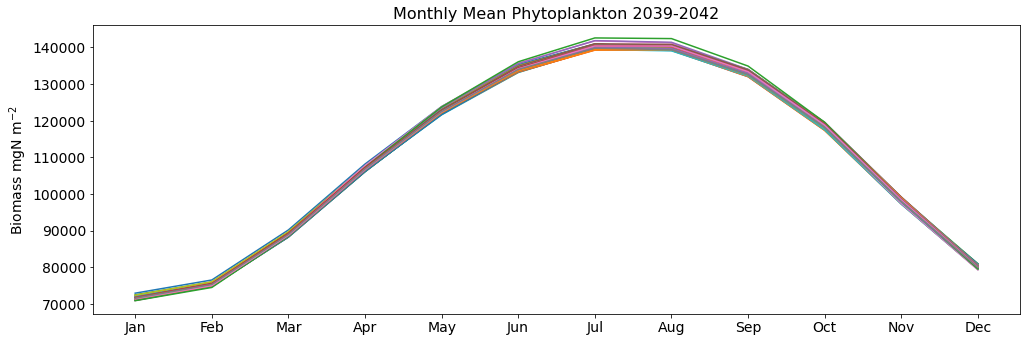

In [11]:
location = groups.salish_sea
fig, ax = plt.subplots(figsize=(14, 5))

fig.tight_layout(pad=2.5)

width=0.1
results = []

control_tbl = control.Diatom_N[start:end,location,0:6] + control.PicoPhytopl_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks = np.arange(len(control_monthly_mean)) 
results.append({
            'scenario': 'control',
            'monthly_mean_biomass': control_monthly_mean,
            'monthly_std': control_std
    })

ax.plot(control_monthly_mean, color='grey', label='control') #yerr=control_std, alpha=0.5

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.Diatom_N[start:end,location,0:6] + scenario.PicoPhytopl_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+nm[3]
    ax.plot(scenario_monthly_mean,label=name) #yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,
    
    results.append({
            'scenario': name,
            'monthly_mean_biomass': scenario_monthly_mean,
            'monthly_std': scenario_std
    })

df = pd.DataFrame(results)
df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Monthly_mean_phytoplankton.csv")

ax.set_title('Monthly Mean Phytoplankton 2039-2042',fontsize=16)
#ax.legend(bbox_to_anchor=(1, 1),  fontsize=14) #fontsize=14, loc="upper center", ncol=len(scenario_paths)+1) #upper left
#ax.set_ylim(0,100000)
#ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

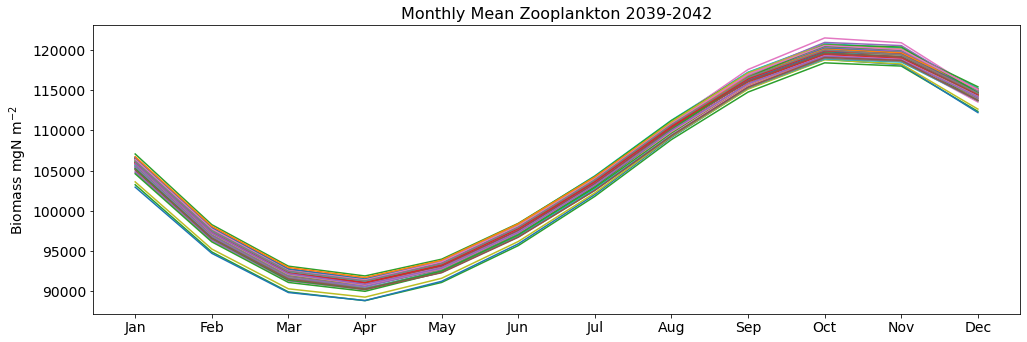

In [10]:
location = groups.salish_sea
fig, ax = plt.subplots(figsize=(14, 5))

fig.tight_layout(pad=2.5)

width=0.1
results = []

control_tbl = control.MicroZoo_N[start:end,location,0:6] + control.Zoo_N[start:end,location,0:6] + control.Gelat_Zoo_N[start:end,location,0:6] + control.Carniv_Zoo_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 
results.append({
            'scenario': 'control',
            'monthly_mean_biomass': control_monthly_mean,
            'monthly_std': control_std
    })

ax.plot(control_monthly_mean,color='grey',label='control') #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.MicroZoo_N[start:end,location,0:6] + scenario.Zoo_N[start:end,location,0:6] + scenario.Gelat_Zoo_N[start:end,location,0:6] + scenario.Carniv_Zoo_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+nm[3]
    ax.plot(scenario_monthly_mean,label=name) #lightgreen
    results.append({
            'scenario': name,
            'monthly_mean_biomass': scenario_monthly_mean,
            'monthly_std': scenario_std
    })
    
df = pd.DataFrame(results)
df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Monthly_mean_zooplankton.csv")

ax.set_title('Monthly Mean Zooplankton 2039-2042',fontsize=16)
#ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14)
#ax.set_ylim(0,35000)
#ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));